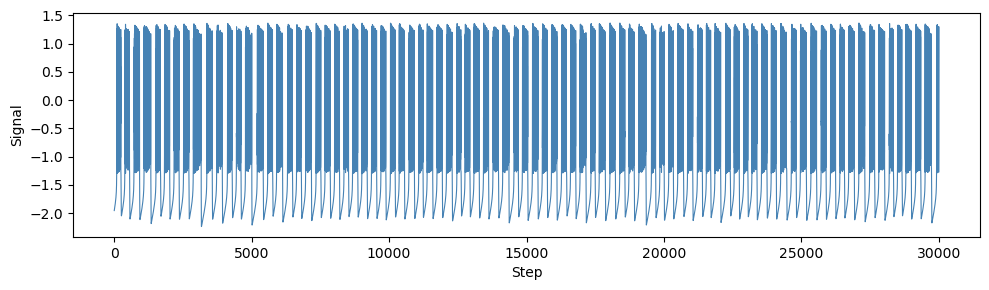

Architecture combos: 72000
Ridge values: 4
Total configs: 288000
Total trials with 3 seeds: 864000

Warming up Numba (compiling JIT kernels)...
  Compilation took 1.8s
[arch 50/72000]  elapsed: 3905s  current best score: 0.210419
[arch 100/72000]  elapsed: 7806s  current best score: 0.036511
[arch 150/72000]  elapsed: 11729s  current best score: 0.036511
[arch 200/72000]  elapsed: 15638s  current best score: 0.013122
[arch 250/72000]  elapsed: 19607s  current best score: 0.013122
[arch 300/72000]  elapsed: 23581s  current best score: 0.013122
[arch 350/72000]  elapsed: 27868s  current best score: 0.013122
[arch 400/72000]  elapsed: 32156s  current best score: 0.013122
[arch 450/72000]  elapsed: 36027s  current best score: 0.013122


KeyboardInterrupt: 

In [1]:
"""
Temporally Multiplexed ESN (TM-ESN) for Rulkov map closed-loop prediction.

Architecture:
  One standard leaky ESN. At each time step the readout receives a stacked
  feature vector:
      f(t) = [x(t), x(t - tau), x(t - 2*tau), ..., x(t - L*tau)]   in R^{(L+1)N}
  Trained as ridge regression on these stacked features.

  Same protocol as LS-ESN v3 (data split, warmup, composite metric, seeds,
  noise injection, sparse W + Numba JIT, ridge caching).
"""

import itertools
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from numba import njit


# ==========================================================
# SCALERS
# ==========================================================
def fit_scaler(X, method="zscore"):
    X = np.asarray(X)
    if method == "none":
        return {"method": "none"}
    if method == "zscore":
        return {"method": "zscore", "mu": X.mean(axis=0), "sd": X.std(axis=0) + 1e-12}
    if method == "minmax01":
        return {"method": "minmax01", "lo": X.min(axis=0), "hi": X.max(axis=0)}
    if method == "minmax11":
        return {"method": "minmax11", "lo": X.min(axis=0), "hi": X.max(axis=0)}
    raise ValueError(method)


def transform_array(X, scaler):
    X = np.asarray(X)
    m = scaler["method"]
    if m == "none":
        return X.copy()
    if m == "zscore":
        return (X - scaler["mu"]) / scaler["sd"]
    if m == "minmax01":
        return (X - scaler["lo"]) / (scaler["hi"] - scaler["lo"] + 1e-12)
    if m == "minmax11":
        return 2.0 * (X - scaler["lo"]) / (scaler["hi"] - scaler["lo"] + 1e-12) - 1.0


def inverse_transform_array(X, scaler):
    X = np.asarray(X)
    m = scaler["method"]
    if m == "none":
        return X.copy()
    if m == "zscore":
        return X * scaler["sd"] + scaler["mu"]
    if m == "minmax01":
        return X * (scaler["hi"] - scaler["lo"]) + scaler["lo"]
    if m == "minmax11":
        return (X + 1.0) / 2.0 * (scaler["hi"] - scaler["lo"]) + scaler["lo"]


# ==========================================================
# NUMBA KERNELS
# ==========================================================
@njit(cache=True, fastmath=True)
def _csr_matvec(data, indices, indptr, x, N):
    out = np.zeros(N)
    for i in range(N):
        s = 0.0
        for jj in range(indptr[i], indptr[i + 1]):
            s += data[jj] * x[indices[jj]]
        out[i] = s
    return out


@njit(cache=True, fastmath=True)
def _step_jit(x_prev, u, W_data, W_idx, W_ptr, Win, bias, lr, N):
    Wu = Win @ u
    Wx = _csr_matvec(W_data, W_idx, W_ptr, x_prev, N)
    out = np.empty(N)
    for i in range(N):
        out[i] = (1.0 - lr) * x_prev[i] + lr * np.tanh(Wu[i] + Wx[i] + bias[i])
    return out


@njit(cache=True, fastmath=True)
def _run_esn_jit(U, W_data, W_idx, W_ptr, Win, bias, lr, N, T):
    """Plain ESN: x(t) = step(x(t-1), u(t)). Returns (T, N) state matrix."""
    X = np.zeros((T, N))
    x = np.zeros(N)
    for t in range(T):
        x = _step_jit(x, U[t], W_data, W_idx, W_ptr, Win, bias, lr, N)
        X[t] = x
    return X


# ==========================================================
# RESERVOIR INITIALIZATION
# ==========================================================
def init_reservoir_weights_sparse(N, D, sr, input_scaling, connectivity, rng):
    W_dense = rng.uniform(-0.5, 0.5, size=(N, N))
    mask = rng.uniform(0.0, 1.0, size=(N, N)) < connectivity
    W_dense = W_dense * mask
    eigs = np.linalg.eigvals(W_dense)
    rho = np.max(np.abs(eigs))
    if rho > 0:
        W_dense = W_dense * (sr / rho)
    W = csr_matrix(W_dense)
    Win = rng.uniform(-input_scaling, input_scaling, size=(N, D))
    bias = rng.uniform(-0.5, 0.5, size=(N,))
    return W, Win, bias


# ==========================================================
# TM-ESN
# ==========================================================
class TMESN:
    """
    Temporally Multiplexed ESN.

    At each time step t the readout sees:
        f(t) = concat([x(t - i*tau) for i in range(L+1)])   shape ((L+1)*N,)
    For t < L*tau the missing past states are filled with zeros (consistent
    with the standard zero-state initialization).
    """

    def __init__(
        self,
        N=1000,
        D=1,
        sr=0.95,
        lr=0.4,
        input_scaling=1.0,
        connectivity=0.1,
        tau=4,            # lag spacing
        L=2,              # number of additional past states (total stack = L+1)
        ridge=1e-6,
        noise_sigma=0.005,
        seed=42,
    ):
        self.N = N
        self.D = D
        self.sr = sr
        self.lr = lr
        self.input_scaling = input_scaling
        self.connectivity = connectivity
        self.tau = int(tau)
        self.L = int(L)
        self.ridge = ridge
        self.noise_sigma = noise_sigma
        self.seed = seed

        rng = np.random.default_rng(seed)
        W, self.Win, self.bias = init_reservoir_weights_sparse(
            N, D, sr, input_scaling, connectivity, rng
        )
        self.W_data, self.W_idx, self.W_ptr = W.data, W.indices, W.indptr

        self.rng_noise = np.random.default_rng(seed + 100)
        self.Wout = None

    # ---------- State collection + multiplexed feature stack ----------
    def collect_states(self, U):
        """Run the reservoir; return the raw state matrix (T, N)."""
        T = len(U)
        return _run_esn_jit(
            U, self.W_data, self.W_idx, self.W_ptr, self.Win,
            self.bias, self.lr, self.N, T
        )

    def stack_features(self, X):
        """
        Build the multiplexed feature matrix from state matrix X (T, N):
        f(t) = [x(t), x(t-tau), ..., x(t-L*tau)], zero-padded for early t.
        Returns (T, (L+1)*N).
        """
        T, N = X.shape
        F = np.zeros((T, (self.L + 1) * N))
        # Lag 0
        F[:, :N] = X
        # Subsequent lags
        for j in range(1, self.L + 1):
            shift = j * self.tau
            if shift < T:
                F[shift:, j * N:(j + 1) * N] = X[:T - shift]
            # for t < shift, the slot stays zero
        return F

    # ---------- Training ----------
    def fit_from_states(self, states, Y, warmup):
        F = self.stack_features(states)
        F_use = F[warmup:]
        Y_use = Y[warmup:]
        FtF = F_use.T @ F_use
        reg = self.ridge * np.eye(FtF.shape[0])
        FtY = F_use.T @ Y_use
        self.Wout = np.linalg.solve(FtF + reg, FtY).T  # (D, (L+1)N)

    def fit(self, U, Y, warmup=500):
        U = np.asarray(U, dtype=float)
        Y = np.asarray(Y, dtype=float)
        if self.noise_sigma > 0:
            U_noisy = U + self.noise_sigma * self.rng_noise.standard_normal(U.shape)
        else:
            U_noisy = U
        states = self.collect_states(U_noisy)
        self.fit_from_states(states, Y, warmup)

    # ---------- Closed-loop prediction ----------
    def closed_loop(self, U_warmup, n_steps):
        """
        Synchronize on U_warmup, then roll out autonomously for n_steps.
        We maintain a buffer of the last L*tau + 1 reservoir states so
        the multiplexed feature vector can be built at each step.
        """
        assert self.Wout is not None, "Call fit() first."

        # Sync on warmup, keep the full state history (we'll use the tail)
        sync_states = self.collect_states(U_warmup)  # (T_w, N)

        max_lag = self.L * self.tau
        # State buffer: last (max_lag + 1) states from sync, padded with zeros
        # if sync was shorter than max_lag.
        T_w = sync_states.shape[0]
        buffer = np.zeros((max_lag + 1, self.N))
        if T_w >= max_lag + 1:
            buffer[:] = sync_states[-(max_lag + 1):]
        else:
            buffer[-T_w:] = sync_states  # leave older slots zero

        x_curr = sync_states[-1].copy()
        u_t = U_warmup[-1].copy()

        preds = np.zeros((n_steps, self.D))

        for step in range(n_steps):
            x_curr = _step_jit(
                x_curr, u_t, self.W_data, self.W_idx, self.W_ptr,
                self.Win, self.bias, self.lr, self.N
            )

            # Slide buffer: drop oldest, append new state at the end
            # buffer[-1] is the most recent
            buffer[:-1] = buffer[1:]
            buffer[-1] = x_curr

            # Build multiplexed feature: [buffer[-1], buffer[-1 - tau], ...]
            feat = np.empty((self.L + 1) * self.N)
            for j in range(self.L + 1):
                idx = (max_lag) - j * self.tau   # position in buffer
                feat[j * self.N:(j + 1) * self.N] = buffer[idx]

            y_hat = self.Wout @ feat
            preds[step] = y_hat
            u_t = y_hat.copy()

        return preds


# ==========================================================
# COMPOSITE METRIC
# ==========================================================
def count_spikes(signal, threshold=0.0):
    s = np.asarray(signal).ravel()
    if len(s) < 3:
        return 0
    is_peak = (s[1:-1] > s[:-2]) & (s[1:-1] > s[2:]) & (s[1:-1] > threshold)
    return int(np.sum(is_peak))


def composite_score(y_true, y_pred, short_horizon=50, alpha=0.5, threshold=0.0):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    h = min(short_horizon, len(y_true))
    err = y_true[:h] - y_pred[:h]
    rmse = np.sqrt(np.mean(err ** 2))
    denom = np.std(y_true[:h])
    nrmse_short = rmse / denom if denom > 0 else np.inf

    n_true = count_spikes(y_true, threshold=threshold)
    n_pred = count_spikes(y_pred, threshold=threshold)
    if n_true == 0:
        spike_pen = 0.0 if n_pred == 0 else 5.0
    else:
        ratio = max(n_pred, 1) / n_true
        spike_pen = abs(np.log(ratio))

    return nrmse_short + alpha * spike_pen, nrmse_short, spike_pen


# ==========================================================
# LOAD DATA
# ==========================================================
dataset = np.loadtxt('../../data/chaotic_data/rulkov_map.csv', delimiter=',')
dataset = dataset[:, 0]

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(dataset[:], color='steelblue', linewidth=0.8)
ax.set_xlabel('Step')
ax.set_ylabel('Signal')
plt.tight_layout()
plt.show()


# ==========================================================
# DATA PREPARATION
# ==========================================================
data = dataset.reshape(-1, 1)
X_raw = data[:-1]
Y_raw = data[1:]


# ==========================================================
# FIXED SETTINGS  (identical to LS-ESN v3 for fair comparison)
# ==========================================================
train_len = 20000
test_start = 22000
test_len = 2000

SEEDS = [42, 7, 2024]

X_train_raw = X_raw[:train_len]
Y_train_raw = Y_raw[:train_len]
X_test_raw = X_raw[test_start:test_start + test_len]
Y_test_raw = Y_raw[test_start:test_start + test_len]

SHORT_HORIZON = 50
ALPHA = 0.5
SPIKE_THRESHOLD = 0.0


# ==========================================================
# DENSE PARAMETER GRID
#
# Since TM-ESN is roughly 3-4x cheaper per config than LS-ESN v3
# (one reservoir update per step instead of three+), we can afford
# a denser grid. Wider ranges on the core ESN parameters; finer
# granularity on the multiplexing dials tau and L.
# ==========================================================
param_grid = {
    "normalization":          ["zscore"],
    "train_warmup":           [500],
    "test_warmup":            [500],
    "units":                  [1000, 2000, 3000],
    "reservoir_connectivity": [0.05, 0.1, 0.2],
    "sr":                     [0.85, 0.9, 0.95, 1.0, 1.05],
    "lr":                     [0.2, 0.3, 0.5, 0.7, 0.9],
    "input_scaling":          [0.3, 0.5, 1.0, 1.5],
    "regression":             [1e-9, 1e-8, 1e-6, 1e-4],
    "tau":                    [1, 2, 4, 8, 16],
    "L":                      [1, 2, 4, 8],
    "noise_sigma":            [0.0, 0.001, 0.005, 0.01],
}

arch_keys = [k for k in param_grid.keys() if k != "regression"]
ridge_values = param_grid["regression"]

arch_combos = list(itertools.product(*[param_grid[k] for k in arch_keys]))
n_total_configs = len(arch_combos) * len(ridge_values)
print(f"Architecture combos: {len(arch_combos)}")
print(f"Ridge values: {len(ridge_values)}")
print(f"Total configs: {n_total_configs}")
print(f"Total trials with {len(SEEDS)} seeds: {n_total_configs * len(SEEDS)}")


# ==========================================================
# JIT WARMUP
# ==========================================================
print("\nWarming up Numba (compiling JIT kernels)...")
_t0 = time.time()
_dummy_rng = np.random.default_rng(0)
_W_dummy, _Win_dummy, _b_dummy = init_reservoir_weights_sparse(50, 1, 0.9, 1.0, 0.2, _dummy_rng)
_U_dummy = np.zeros((20, 1))
_run_esn_jit(_U_dummy, _W_dummy.data, _W_dummy.indices, _W_dummy.indptr,
             _Win_dummy, _b_dummy, 0.3, 50, 20)
print(f"  Compilation took {time.time() - _t0:.1f}s")


# ==========================================================
# EVALUATION (architecture-level, ridge-cached)
# ==========================================================
def evaluate_architecture_one_seed(arch_params, ridge_values, seed):
    out = {r: (np.inf, np.inf, np.inf) for r in ridge_values}
    try:
        if arch_params["test_warmup"] >= test_len:
            return out

        scaler = fit_scaler(X_train_raw, method=arch_params["normalization"])
        X_train = transform_array(X_train_raw, scaler)
        Y_train = transform_array(Y_train_raw, scaler)
        X_test = transform_array(X_test_raw, scaler)
        Y_test = transform_array(Y_test_raw, scaler)

        pred_len = test_len - arch_params["test_warmup"]
        Y_true_scaled = Y_test[arch_params["test_warmup"]:arch_params["test_warmup"] + pred_len, 0]

        if arch_params["train_warmup"] >= len(X_train):
            return out

        model = TMESN(
            N=int(arch_params["units"]),
            D=1,
            sr=arch_params["sr"],
            lr=arch_params["lr"],
            input_scaling=arch_params["input_scaling"],
            connectivity=arch_params["reservoir_connectivity"],
            tau=arch_params["tau"],
            L=arch_params["L"],
            ridge=ridge_values[0],
            noise_sigma=arch_params["noise_sigma"],
            seed=seed,
        )

        # Collect states once per (architecture, seed)
        if model.noise_sigma > 0:
            U_noisy = X_train + model.noise_sigma * model.rng_noise.standard_normal(X_train.shape)
        else:
            U_noisy = X_train
        states = model.collect_states(U_noisy)

        for ridge in ridge_values:
            model.ridge = ridge
            try:
                model.fit_from_states(states, Y_train, arch_params["train_warmup"])
                preds = model.closed_loop(X_test[:arch_params["test_warmup"]], n_steps=pred_len)
                Y_pred_scaled = preds[:, 0]

                if np.any(np.isnan(Y_pred_scaled)) or np.any(np.isinf(Y_pred_scaled)):
                    continue
                if np.max(np.abs(Y_pred_scaled)) > 1e6:
                    continue

                score, nrmse_short, spike_pen = composite_score(
                    Y_true_scaled, Y_pred_scaled,
                    short_horizon=SHORT_HORIZON,
                    alpha=ALPHA,
                    threshold=SPIKE_THRESHOLD,
                )
                out[ridge] = (score, nrmse_short, spike_pen)
            except Exception as e:
                print(f"    ridge inner ERROR: {e}")
                continue

        return out

    except Exception as e:
        print(f"    arch ERROR: {e}")
        return out


def evaluate_architecture(arch_params, ridge_values, seeds=SEEDS):
    per_seed = [evaluate_architecture_one_seed(arch_params, ridge_values, s) for s in seeds]
    averaged = {}
    for r in ridge_values:
        scores = [p[r][0] for p in per_seed]
        nrmses = [p[r][1] for p in per_seed]
        spikes = [p[r][2] for p in per_seed]
        averaged[r] = (
            float(np.mean(scores)),
            float(np.mean(nrmses)),
            float(np.mean(spikes)),
        )
    return averaged


# ==========================================================
# RUN GRID SEARCH
# ==========================================================
results = []
best_score = np.inf
best_params = None
t_start = time.time()

for i, combo in enumerate(arch_combos):
    arch_params = dict(zip(arch_keys, combo))
    ridge_results = evaluate_architecture(arch_params, ridge_values)

    for ridge, (score, nrmse_short, spike_pen) in ridge_results.items():
        full_params = {**arch_params, "regression": ridge}
        results.append({
            **full_params,
            "score": score,
            "nrmse_short": nrmse_short,
            "spike_pen": spike_pen,
        })
        if score < best_score:
            best_score = score
            best_params = full_params.copy()

    if (i + 1) % 50 == 0 or (i + 1) == len(arch_combos):
        elapsed = time.time() - t_start
        print(
            f"[arch {i+1}/{len(arch_combos)}]  elapsed: {elapsed:.0f}s  "
            f"current best score: {best_score:.6f}"
        )

total_time = time.time() - t_start


# ==========================================================
# RESULTS
# ==========================================================
print("\n" + "=" * 80)
print("GRID SEARCH COMPLETE")
print(f"Train interval        : [0 : {train_len}]")
print(f"Test interval         : [{test_start} : {test_start + test_len}]")
print(f"Seeds per config      : {len(SEEDS)}")
print(f"Architecture combos   : {len(arch_combos)}")
print(f"Total configs         : {n_total_configs}")
print(f"Total time            : {total_time:.1f}s "
      f"({total_time / len(arch_combos):.2f}s per architecture)")
print(f"Best composite        : {best_score:.6f}")
print("Best parameters:")
for key, v in best_params.items():
    print(f"  {key:24s} = {v}")
print("=" * 80)

results_sorted = sorted(results, key=lambda r: r["score"])
print("\nTop 10 configurations:")
print(
    f"{'Rank':>4}  {'units':>5}  {'sr':>5}  {'lr':>5}  "
    f"{'in_sc':>6}  {'reg':>9}  {'tau':>4}  {'L':>3}  "
    f"{'noise':>7}  {'score':>8}  {'nrmseS':>8}  {'spike':>7}"
)
print("-" * 105)
for rank, r in enumerate(results_sorted[:10], 1):
    print(
        f"{rank:4d}  "
        f"{int(r['units']):5d}  "
        f"{r['sr']:5.2f}  "
        f"{r['lr']:5.2f}  "
        f"{r['input_scaling']:6.2f}  "
        f"{r['regression']:9.1e}  "
        f"{r['tau']:4d}  "
        f"{r['L']:3d}  "
        f"{r['noise_sigma']:7.4f}  "
        f"{r['score']:8.4f}  "
        f"{r['nrmse_short']:8.4f}  "
        f"{r['spike_pen']:7.4f}"
    )


# ==========================================================
# REBUILD BEST MODEL (first seed)
# ==========================================================
best_scaler = fit_scaler(X_train_raw, method=best_params["normalization"])
X_train_best = transform_array(X_train_raw, best_scaler)
Y_train_best = transform_array(Y_train_raw, best_scaler)
X_test_best = transform_array(X_test_raw, best_scaler)
Y_test_best = transform_array(Y_test_raw, best_scaler)

best_pred_len = test_len - best_params["test_warmup"]

best_model = TMESN(
    N=int(best_params["units"]),
    D=1,
    sr=best_params["sr"],
    lr=best_params["lr"],
    input_scaling=best_params["input_scaling"],
    connectivity=best_params["reservoir_connectivity"],
    tau=best_params["tau"],
    L=best_params["L"],
    ridge=best_params["regression"],
    noise_sigma=best_params["noise_sigma"],
    seed=SEEDS[0],
)
best_model.fit(X_train_best, Y_train_best, warmup=best_params["train_warmup"])
preds_best_scaled = best_model.closed_loop(
    X_test_best[:best_params["test_warmup"]],
    n_steps=best_pred_len,
)
Y_pred_best = inverse_transform_array(preds_best_scaled, best_scaler).ravel()
Y_true_best = inverse_transform_array(
    Y_test_best[best_params["test_warmup"]:best_params["test_warmup"] + best_pred_len],
    best_scaler,
).ravel()

mse = np.mean((Y_true_best - Y_pred_best) ** 2)
rmse = np.sqrt(mse)
nrmse_full = rmse / np.std(Y_true_best)
short = min(SHORT_HORIZON, len(Y_true_best))
nrmse_short = np.sqrt(np.mean((Y_true_best[:short] - Y_pred_best[:short]) ** 2)) / np.std(Y_true_best[:short])
n_true_spikes = count_spikes(Y_true_best, threshold=SPIKE_THRESHOLD)
n_pred_spikes = count_spikes(Y_pred_best, threshold=SPIKE_THRESHOLD)

print("\nFinal best-model metrics (original scale, single seed):")
print(f"MSE (full)        : {mse:.10f}")
print(f"NRMSE (full)      : {nrmse_full:.6f}")
print(f"NRMSE (first {short}) : {nrmse_short:.6f}")
print(f"Spikes true       : {n_true_spikes}")
print(f"Spikes predicted  : {n_pred_spikes}")
print(f"Spike ratio       : {n_pred_spikes / max(n_true_spikes, 1):.3f}")


# ==========================================================
# VISUALIZATION
# ==========================================================
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(
    np.arange(test_len),
    Y_test_raw[:, 0],
    c="green",
    label="Ground truth",
    linewidth=1.2,
)
ax.axvline(
    best_params["test_warmup"],
    linestyle="--",
    c="k",
    linewidth=1.0,
    label="Warmup end",
)
ax.plot(
    np.arange(best_params["test_warmup"], best_params["test_warmup"] + best_pred_len),
    Y_pred_best,
    linestyle="--",
    c="red",
    linewidth=1.2,
    label="TM-ESN closed-loop prediction",
)
ax.set_title(
    f"TM-ESN Closed-Loop | composite={best_score:.3f} | "
    f"NRMSE(50)={nrmse_short:.3f} | spikes {n_pred_spikes}/{n_true_spikes} | "
    f"N={int(best_params['units'])}, tau={best_params['tau']}, L={best_params['L']}, "
    f"noise={best_params['noise_sigma']}"
)
ax.set_xlabel("Step within chosen test window")
ax.set_ylabel("Signal")
ax.legend()
plt.tight_layout()
plt.show()


Final best-model metrics (original scale, single seed):
MSE (full)        : 0.9356661672
NRMSE (full)      : 0.949045
NRMSE (first 50) : 0.002273
Spikes true       : 209
Spikes predicted  : 206
Spike ratio       : 0.986


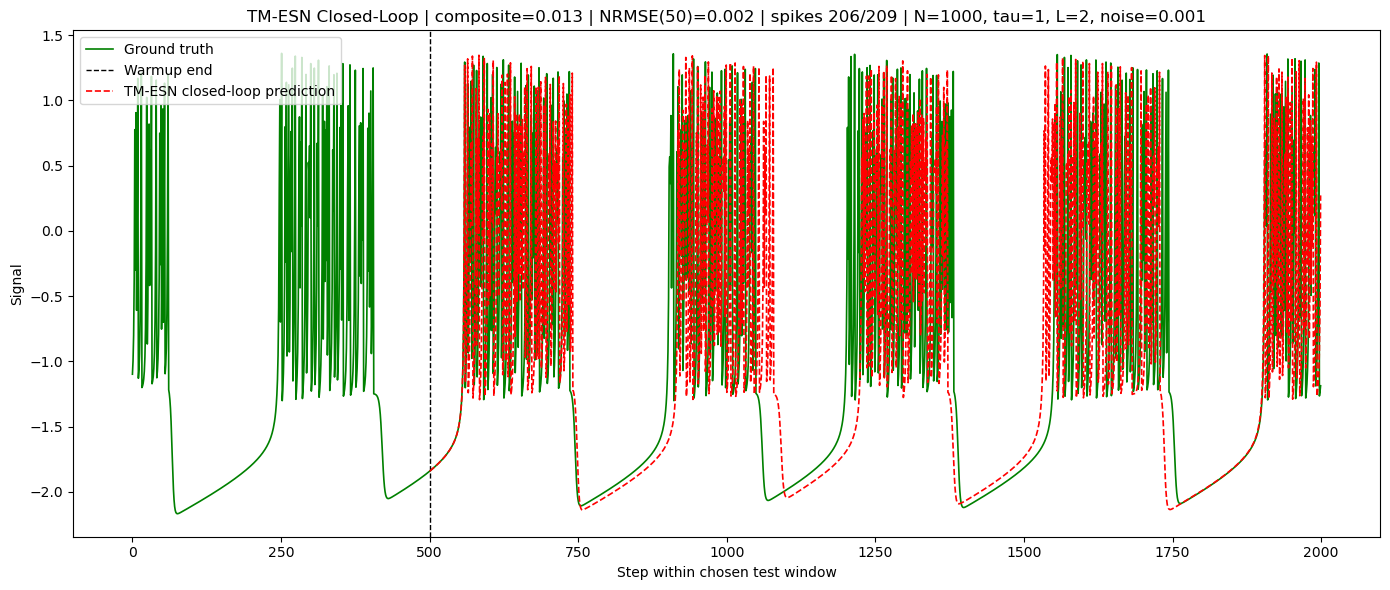

In [2]:


# ==========================================================
# REBUILD BEST MODEL (first seed)
# ==========================================================
best_scaler = fit_scaler(X_train_raw, method=best_params["normalization"])
X_train_best = transform_array(X_train_raw, best_scaler)
Y_train_best = transform_array(Y_train_raw, best_scaler)
X_test_best = transform_array(X_test_raw, best_scaler)
Y_test_best = transform_array(Y_test_raw, best_scaler)

best_pred_len = test_len - best_params["test_warmup"]

best_model = TMESN(
    N=int(best_params["units"]),
    D=1,
    sr=best_params["sr"],
    lr=best_params["lr"],
    input_scaling=best_params["input_scaling"],
    connectivity=best_params["reservoir_connectivity"],
    tau=best_params["tau"],
    L=best_params["L"],
    ridge=best_params["regression"],
    noise_sigma=best_params["noise_sigma"],
    seed=SEEDS[0],
)
best_model.fit(X_train_best, Y_train_best, warmup=best_params["train_warmup"])
preds_best_scaled = best_model.closed_loop(
    X_test_best[:best_params["test_warmup"]],
    n_steps=best_pred_len,
)
Y_pred_best = inverse_transform_array(preds_best_scaled, best_scaler).ravel()
Y_true_best = inverse_transform_array(
    Y_test_best[best_params["test_warmup"]:best_params["test_warmup"] + best_pred_len],
    best_scaler,
).ravel()

mse = np.mean((Y_true_best - Y_pred_best) ** 2)
rmse = np.sqrt(mse)
nrmse_full = rmse / np.std(Y_true_best)
short = min(SHORT_HORIZON, len(Y_true_best))
nrmse_short = np.sqrt(np.mean((Y_true_best[:short] - Y_pred_best[:short]) ** 2)) / np.std(Y_true_best[:short])
n_true_spikes = count_spikes(Y_true_best, threshold=SPIKE_THRESHOLD)
n_pred_spikes = count_spikes(Y_pred_best, threshold=SPIKE_THRESHOLD)

print("\nFinal best-model metrics (original scale, single seed):")
print(f"MSE (full)        : {mse:.10f}")
print(f"NRMSE (full)      : {nrmse_full:.6f}")
print(f"NRMSE (first {short}) : {nrmse_short:.6f}")
print(f"Spikes true       : {n_true_spikes}")
print(f"Spikes predicted  : {n_pred_spikes}")
print(f"Spike ratio       : {n_pred_spikes / max(n_true_spikes, 1):.3f}")


# ==========================================================
# VISUALIZATION
# ==========================================================
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(
    np.arange(test_len),
    Y_test_raw[:, 0],
    c="green",
    label="Ground truth",
    linewidth=1.2,
)
ax.axvline(
    best_params["test_warmup"],
    linestyle="--",
    c="k",
    linewidth=1.0,
    label="Warmup end",
)
ax.plot(
    np.arange(best_params["test_warmup"], best_params["test_warmup"] + best_pred_len),
    Y_pred_best,
    linestyle="--",
    c="red",
    linewidth=1.2,
    label="TM-ESN closed-loop prediction",
)
ax.set_title(
    f"TM-ESN Closed-Loop | composite={best_score:.3f} | "
    f"NRMSE(50)={nrmse_short:.3f} | spikes {n_pred_spikes}/{n_true_spikes} | "
    f"N={int(best_params['units'])}, tau={best_params['tau']}, L={best_params['L']}, "
    f"noise={best_params['noise_sigma']}"
)
ax.set_xlabel("Step within chosen test window")
ax.set_ylabel("Signal")
ax.legend()
plt.tight_layout()
plt.show()